# DSF-Midterm Project
Answers to the questions in the instruction document will be shown in this notebook.

## <font color='blue'> 0. Import all necessary Libraries </font>

In [1]:
# Import all necessary libraries
# rdkit had to be imported as a whole as cell 5 would give an error message mistaking library name as variable

from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

!pip install rdkit
!pip install tensorflow
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
import pandas as pd
import numpy as np
import rdkit
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

print("finished")
%matplotlib inline

# Allow mulitple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


I0000 00:00:1776257353.529623 3672657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776257353.533809 3672657 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776257353.574713 3672657 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776257371.412828 3672657 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

finished


In [2]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

### <font color='blue'> 1. Data preparation </font>
Load table and use important columns

In [3]:
# Load data
df = pd.read_csv(DATA / "kinase.csv", index_col=0)
df = df.reset_index(drop=True)
df.head()

# Check the dimension and missing value of the data
### Size and info of training set
print("Shape of dataframe : ", df.shape)
df.info()

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,smiles
0,CHEMBL13462,4000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
1,CHEMBL13462,16000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
2,CHEMBL13462,800.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
3,CHEMBL13462,9000.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
4,CHEMBL13462,1700.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...


Shape of dataframe :  (179827, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179827 entries, 0 to 179826
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   molecule_chembl_id  179827 non-null  object 
 1   standard_value      179827 non-null  float64
 2   standard_units      179827 non-null  object 
 3   target_chembl_id    179827 non-null  object 
 4   smiles              179827 non-null  object 
dtypes: float64(1), object(4)
memory usage: 6.9+ MB


In [4]:
# Modifying data
# Eliminate 0-values from standard_value
chembl_df = df.copy()
chembl_df = chembl_df[chembl_df["standard_value"] > 0].copy()
#turn values into pIC50
chembl_df["pIC50"]=(-1)*np.log10(chembl_df["standard_value"]/(1000000000))
#keep necessary columns
chembl_df = chembl_df[["smiles","pIC50"]]
chembl_df.head()

,smiles,pIC50
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.397940
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.795880
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,6.096910
3,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.045757
4,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.769551


### <font color='blue'> 2. Molecular encoding</font>

In [5]:
### Fingerprints are a better format for machines to read
### MACCS are most commonly used. It has 166 bits that encode substructures.
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = rdkit.Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [6]:
# Converting SMILES to MACCS fingerprints
chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)
# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# copy dataset
chembl_df2 = chembl_df.copy()

Shape of dataframe: (179154, 3)


,smiles,pIC50,fingerprints_df
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.39794,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.79588,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,6.09691,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
### Test sets are a fraction of the data set which is used to evaluate the performance of the training set
### The neural network model is challenged by the test set by comparing the prediction set and the test set which isn't used in the training step
### External data sets that aren't part of the data set are used to evaluate the prediction efficacy and possible biases

# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df2["fingerprints_df"], chembl_df2["pIC50"], test_size=0.3, random_state=42
)
# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

Shape of training data: (125407,)
Shape of test data: (53747,)


### <font color='blue'> 3. Define Neural Network </font>

In [8]:
### Defining number of layers and neurons within
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

### <font color='blue'> 4. Train The Model </font>


In [9]:
# Neural network parameters
# batches are subparts of training set, here three different batch sizes are individually tested
batch_sizes = [16, 32, 64]
# Epoch = One full run of training set
nb_epoch = 50
# number of neurons in hidden layers
layer1_size = 64
layer2_size = 32

<Axes: >

E0000 00:00:1776257581.500348 3672657 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 8s 943us/step - loss: 1.5119 - mae: 0.9692 - mse: 1.5119 - val_loss: 1.3153 - val_mae: 0.9267 - val_mse: 1.3153
Epoch 2/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 7s 920us/step - loss: 1.2725 - mae: 0.9062 - mse: 1.2725 - val_loss: 1.2788 - val_mae: 0.8986 - val_mse: 1.2788
Epoch 3/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 1.2089 - mae: 0.8822 - mse: 1.2089 - val_loss: 1.3100 - val_mae: 0.9254 - val_mse: 1.3100
Epoch 4/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 7s 904us/step - loss: 1.1664 - mae: 0.8651 - mse: 1.1664 - val_loss: 1.1730 - val_mae: 0.8671 - val_mse: 1.1730
Epoch 5/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 7s 919us/step - loss: 1.1385 - mae: 0.8541 - mse: 1.1385 - val_loss: 1.2061 - val_mae: 0.8718 - val_mse: 1.2061
Epoch 6/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 7s 920us/step - loss: 1.1126 - mae: 0.8426 - mse: 1.1126 - val_loss: 1.1449 - val_mae: 0.8582 - val_mse: 1.1449
Epoch 7/50
7838/7838 ━━━━━━━━━━━━━━━━━━━━ 7s 911us/step - loss: 1.0943 - mae: 

Text(0, 0.5, 'loss')

Text(0.5, 0, 'epoch')

...

Epoch 1/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.6302 - mae: 0.9974 - mse: 1.6302 - val_loss: 1.4012 - val_mae: 0.9581 - val_mse: 1.4012
Epoch 2/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - loss: 1.3062 - mae: 0.9191 - mse: 1.3062 - val_loss: 1.2928 - val_mae: 0.9089 - val_mse: 1.2928
Epoch 3/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.2416 - mae: 0.8948 - mse: 1.2416 - val_loss: 1.2338 - val_mae: 0.8882 - val_mse: 1.2338
Epoch 4/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1988 - mae: 0.8778 - mse: 1.1988 - val_loss: 1.2149 - val_mae: 0.8793 - val_mse: 1.2149
Epoch 5/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1654 - mae: 0.8647 - mse: 1.1654 - val_loss: 1.1695 - val_mae: 0.8632 - val_mse: 1.1695
Epoch 6/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1356 - mae: 0.8531 - mse: 1.1356 - val_loss: 1.1933 - val_mae: 0.8706 - val_mse: 1.1933
Epoch 7/50
1960/1960 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1120 - mae: 0.8437 - m

Text(0, 0.5, 'loss')

Text(0.5, 0, 'epoch')

(0.0, 2.0)

Text(0.5, 1.0, 'test loss = 1.03, batch size = 64')

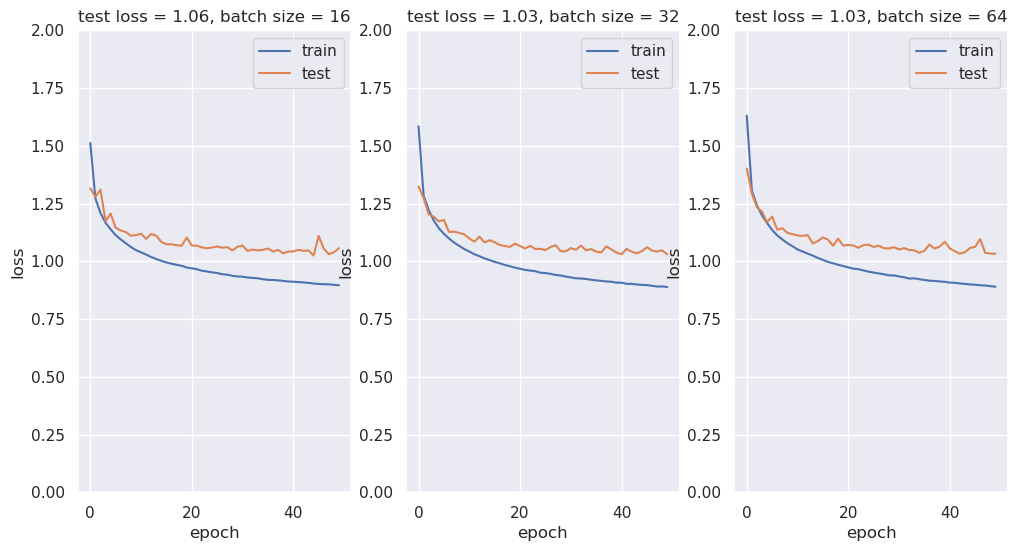

In [10]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
tstlss = {}
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=1,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 2))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
    tstlss.update({str(batch):history.history['val_loss'][nb_epoch-1]})
plt.show()

In [ ]:
# Save the trained model
# weighting factor and bias factor saved as a seperate file, are tuned for improving model performance 
filepath = DATA / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=1,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model, further training
# batch_size configured to always choose the one with the smallest test loss
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=int([k for k, v in tstlss.items() if v == min(tstlss.values())][0]),
    callbacks=callbacks_list,
    verbose=1,
)

Epoch 1/50
3903/3919 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step - loss: 0.9244 - mae: 0.7622 - mse: 0.9244
Epoch 1: loss improved from None to 0.92290, saving model to /storage/homefs/xc20t071/data/best_weights.weights.h5

Epoch 1: finished saving model to /storage/homefs/xc20t071/data/best_weights.weights.h5
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 3s 721us/step - loss: 0.9229 - mae: 0.7621 - mse: 0.9229
Epoch 2/50
3885/3919 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 0.9021 - mae: 0.7528 - mse: 0.9021
Epoch 2: loss improved from 0.92290 to 0.91397, saving model to /storage/homefs/xc20t071/data/best_weights.weights.h5

Epoch 2: finished saving model to /storage/homefs/xc20t071/data/best_weights.weights.h5
3919/3919 ━━━━━━━━━━━━━━━━━━━━ 5s 684us/step - loss: 0.9140 - mae: 0.7582 - mse: 0.9140
Epoch 3/50
3868/3919 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.9064 - mae: 0.7552 - mse: 0.9064
Epoch 3: loss improved from 0.91397 to 0.91340, saving model to /storage/homefs/xc20t071/data/best_weights.weights.h

### <font color='blue'> 5. Evaluation & prediction on test set </font>

In [ ]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

In [ ]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

#### <font color='red'> Scatter Plot </font>

In [ ]:
# Scatter plot
# ideally points would be on the x = y line, the closer the better
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

#### <font color='cerulean'> Prediction on external/unlabeled data </font>

In [ ]:
# Load external/unlabeled data set
ext_df = pd.read_csv(DATA / "EGFR external.csv", index_col=0, sep=";")
ext_df = ext_df.reset_index(drop=True)
ext_df.head()

In [ ]:
# Modifying data
# Eliminate 0-values from standard_value
chembl_ext_df = ext_df.copy()
chembl_ext_df = chembl_ext_df[chembl_ext_df["Standard Value"] > 0].copy()
chembl_ext_df = chembl_ext_df[chembl_ext_df["Standard Units"] == "nM"].copy()
#turn values into pIC50
chembl_ext_df["pIC50"]=(-1)*np.log10(chembl_ext_df["Standard Value"]/(1000000000))
#keep necessary columns
chembl_ext_df = chembl_ext_df[["Smiles","pIC50"]]
chembl_ext_df.head()

In [ ]:
# Convert SMILES strings to MACCS fingerprints
chembl_ext_df["fingerprints_df"] = chembl_ext_df["Smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", chembl_ext_df.shape)
chembl_ext_df.head(3)

In [ ]:
# Prediction on external/unlabeled data
predictions = model.predict(
    np.array(list((chembl_ext_df["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = chembl_ext_df.join(predicted_pIC50)

predicted_pIC50_df.head(3)

In [ ]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(DATA / "predicted_pIC50_df.csv")

In [ ]:
# Scatter plot
# ideally points would be on the x = y line, the closer the better
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(predicted_pIC50_df["predicted_pIC50"], predicted_pIC50_df["pIC50"], marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

In [ ]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv(DATA / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

In [ ]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["Smiles"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)

### Discussion

Predicted pIC50 values differ greatly from the true values.